In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import sys
sys.path.insert(0, '../src')
from kl import load_kl_records

kl_path = '../data/kl_seed42_embd16_layer1_blk16_interval10.npz'
records = load_kl_records(kl_path)
for order, (steps, vals) in sorted(records.items()):
    print(f"order={order}: {len(steps)} entries, steps {steps[0]}..{steps[-1]}, KL range [{vals.min():.4f}, {vals.max():.4f}]")

order=1: 100 entries, steps 0..990, KL range [0.2497, 0.6910]
order=2: 100 entries, steps 0..990, KL range [0.1296, 1.7162]
order=3: 100 entries, steps 0..990, KL range [0.4513, 6.0340]
order=4: 100 entries, steps 0..990, KL range [0.9096, 10.4532]


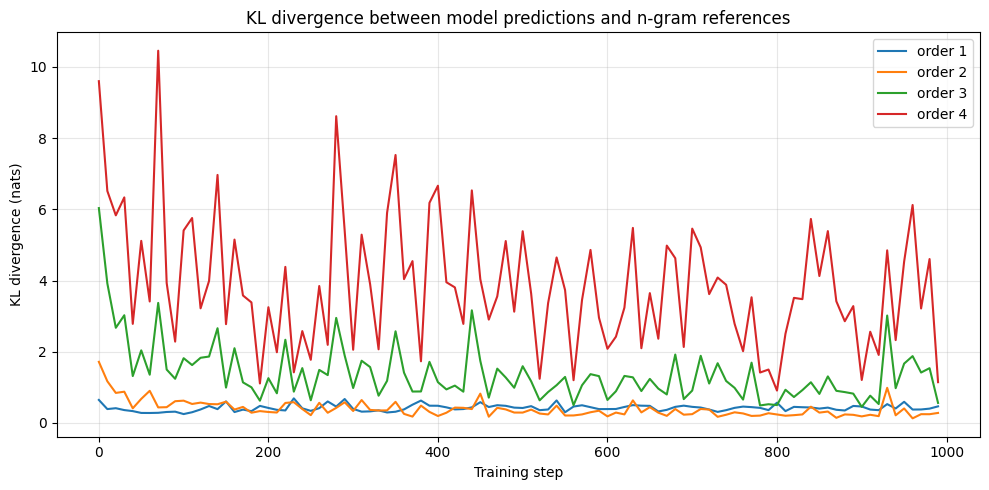

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for order, (steps, vals) in sorted(records.items()):
    ax.plot(steps, vals, label=f'order {order}')

ax.set_xlabel('Training step')
ax.set_ylabel('KL divergence (nats)')
ax.set_title('KL divergence between model predictions and n-gram references')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
from ngrams import load_ngrams

ngrams_path = '../data/ngrams.npz'
ngrams = load_ngrams(ngrams_path)

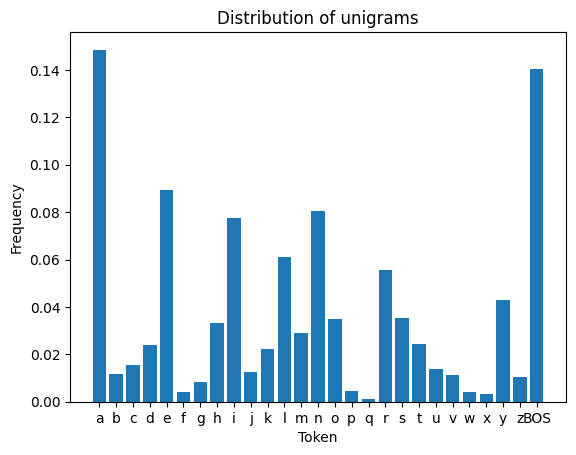

In [7]:
tokens = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'BOS']
plt.bar(tokens, ngrams[1][0]);
plt.ylabel("Frequency");
plt.xlabel("Token");
plt.title("Distribution of unigrams");

In [8]:
def bigram_distribution(token):
    """Return P(next_char | token) as a numpy array over all 27 tokens."""
    if token not in tokens:
        raise ValueError(f"'{token}' is not a valid token. Must be one of: {tokens}")
    idx = tokens.index(token)
    probs, seen = ngrams[2]
    if not seen[idx]:
        raise ValueError(f"'{token}' was never seen as a context in the training data.")
    return probs[idx]  # shape (27,), sums to 1.0


# example
# dist = bigram_distribution('a')
# for tok, p in zip(tokens, dist):
#     if p > 0:
#         print(f"P(next='{tok}' | 'a') = {p:.4f}")

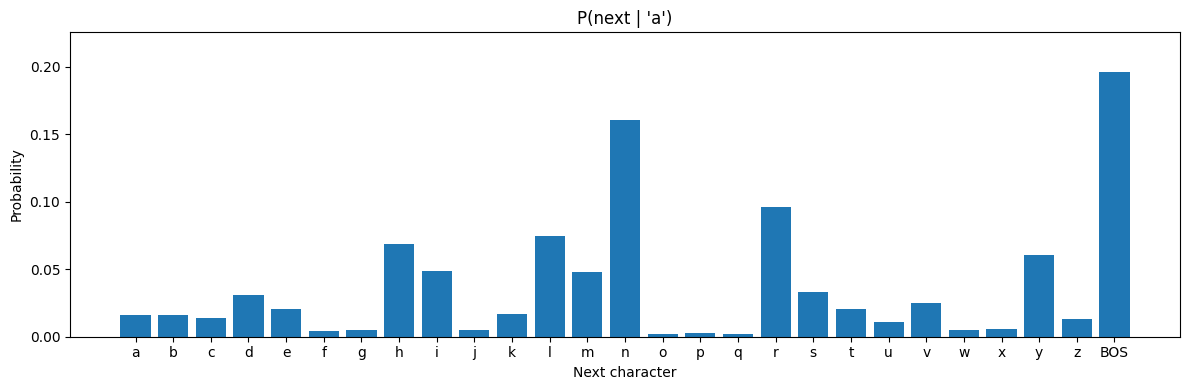

In [9]:
def plot_bigram_distribution(token):
    dist = bigram_distribution(token)
    label = 'BOS' if token == 'BOS' else f"'{token}'"

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(tokens, dist)
    ax.set_xlabel('Next character')
    ax.set_ylabel('Probability')
    ax.set_title(f'P(next | {label})')
    ax.set_ylim(0, max(dist) * 1.15)
    plt.tight_layout()
    plt.show()

plot_bigram_distribution('a')

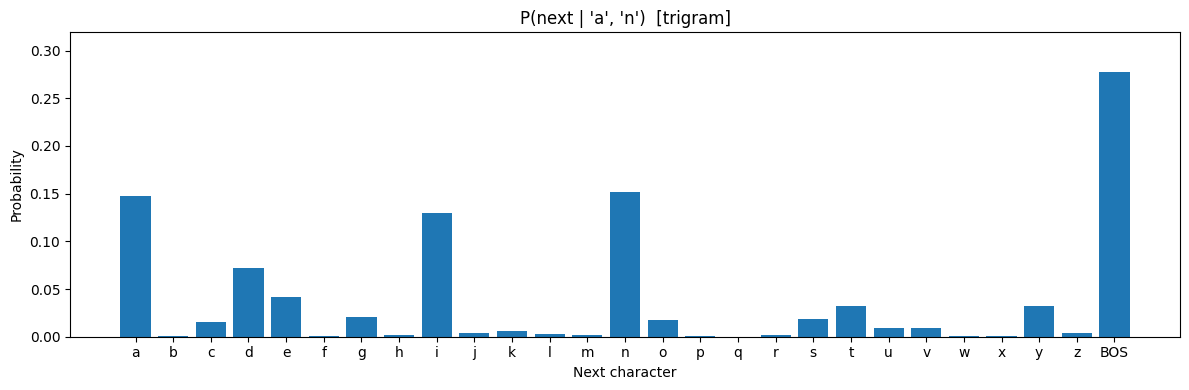

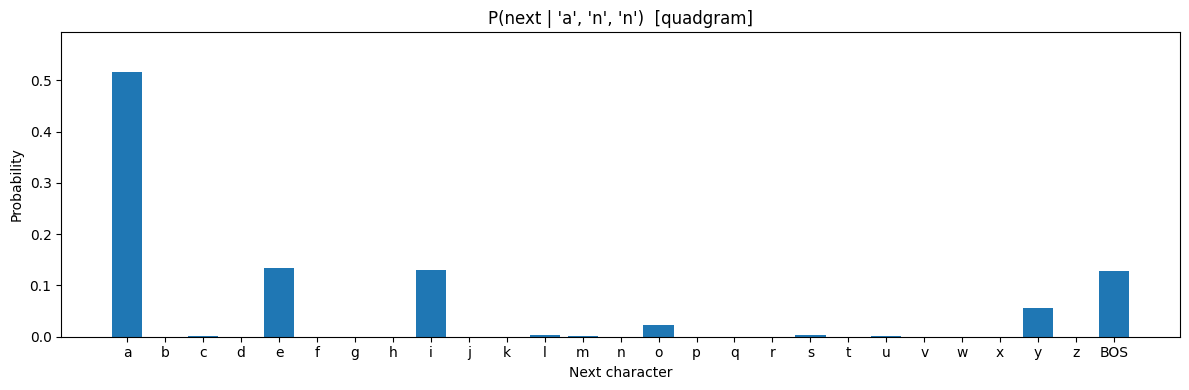

In [10]:
# Helper accessors for each order's (probs, seen_mask) tables
def get_trigram_table():
    return ngrams[3]   # probs shape (27,27,27), seen shape (27,27)

def get_quadgram_table():
    return ngrams[4]   # probs shape (27,27,27,27), seen shape (27,27,27)


def ngram_distribution(context):
    """
    Return P(next | context) as a 27-element array.

    context : list of 1–3 valid tokens ('a'–'z' or 'BOS')
              len 1 → bigram, len 2 → trigram, len 3 → quadgram
    """
    order = len(context) + 1
    if order not in ngrams:
        raise ValueError(f"No {order}-gram data available (context length must be 1–3).")
    for tok in context:
        if tok not in tokens:
            raise ValueError(f"'{tok}' is not a valid token. Choose from: {tokens}")
    ctx_idx = tuple(tokens.index(tok) for tok in context)
    probs, seen = ngrams[order]
    if not seen[ctx_idx]:
        raise ValueError(f"Context {context} was never seen in the training data.")
    return probs[ctx_idx]


def plot_ngram_distribution(context):
    dist = ngram_distribution(context)
    order = len(context) + 1
    order_name = {2: 'bigram', 3: 'trigram', 4: 'quadgram'}.get(order, f'{order}-gram')
    ctx_label = ', '.join(f"'{t}'" if t != 'BOS' else 'BOS' for t in context)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(tokens, dist)
    ax.set_xlabel('Next character')
    ax.set_ylabel('Probability')
    ax.set_title(f'P(next | {ctx_label})  [{order_name}]')
    ax.set_ylim(0, max(dist) * 1.15)
    plt.tight_layout()
    plt.show()


# trigram example: P(next | 'a', 'n')
plot_ngram_distribution(['a', 'n'])

# quadgram example: P(next | 'a', 'n', 'n')
plot_ngram_distribution(['a', 'n', 'n'])

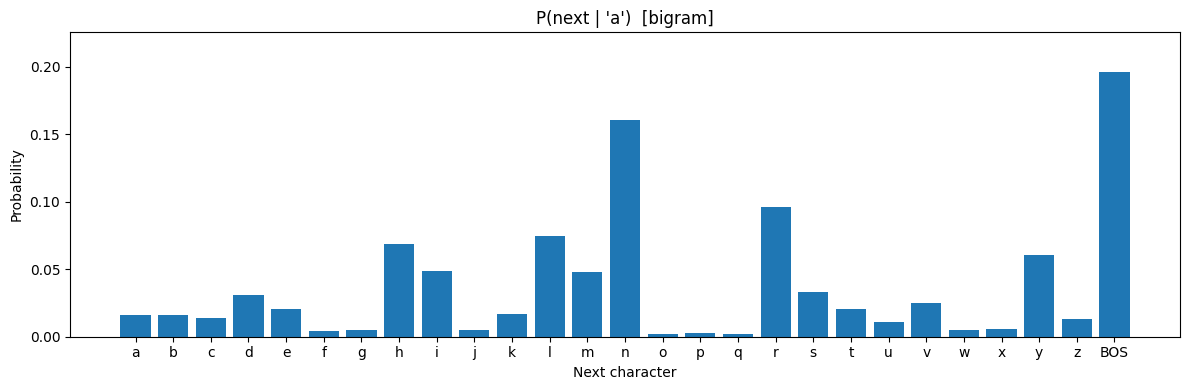

In [11]:
plot_ngram_distribution(['a'])

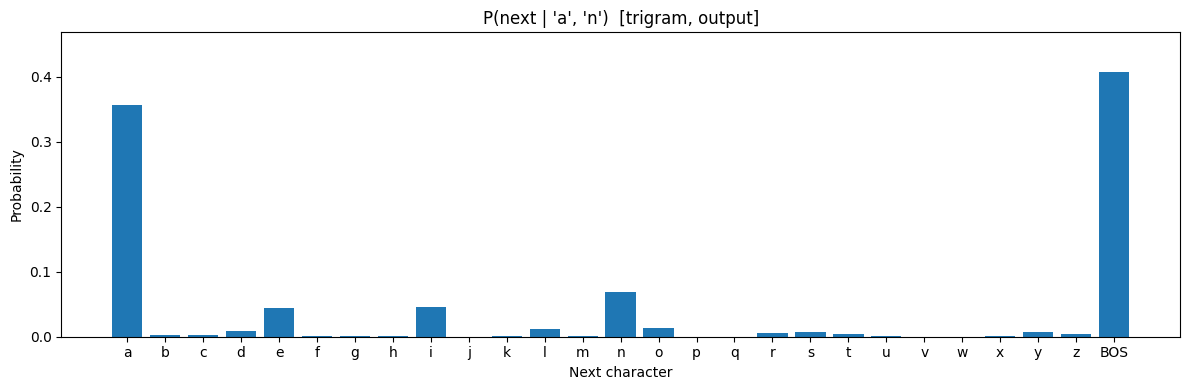

In [12]:
output_ngrams_path = '../data/output_ngrams_seed42_embd16_layer1_blk16_n3200.npz'
output_ngrams = load_ngrams(output_ngrams_path)


def output_ngram_distribution(context):
    """
    Return P(next | context) from the model's inference output n-grams.

    context : list of 1–3 valid tokens ('a'–'z' or 'BOS')
              len 1 → bigram, len 2 → trigram, len 3 → quadgram
    """
    order = len(context) + 1
    if order not in output_ngrams:
        raise ValueError(f"No {order}-gram data available (context length must be 1–3).")
    for tok in context:
        if tok not in tokens:
            raise ValueError(f"'{tok}' is not a valid token. Choose from: {tokens}")
    ctx_idx = tuple(tokens.index(tok) for tok in context)
    probs, seen = output_ngrams[order]
    if not seen[ctx_idx]:
        raise ValueError(f"Context {context} was never seen in the inference output.")
    return probs[ctx_idx]


def plot_output_ngram_distribution(context):
    dist = output_ngram_distribution(context)
    order = len(context) + 1
    order_name = {2: 'bigram', 3: 'trigram', 4: 'quadgram'}.get(order, f'{order}-gram')
    ctx_label = ', '.join(f"'{t}'" if t != 'BOS' else 'BOS' for t in context)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(tokens, dist)
    ax.set_xlabel('Next character')
    ax.set_ylabel('Probability')
    ax.set_title(f'P(next | {ctx_label})  [{order_name}, output]')
    ax.set_ylim(0, max(dist) * 1.15)
    plt.tight_layout()
    plt.show()


plot_output_ngram_distribution(['a', 'n'])

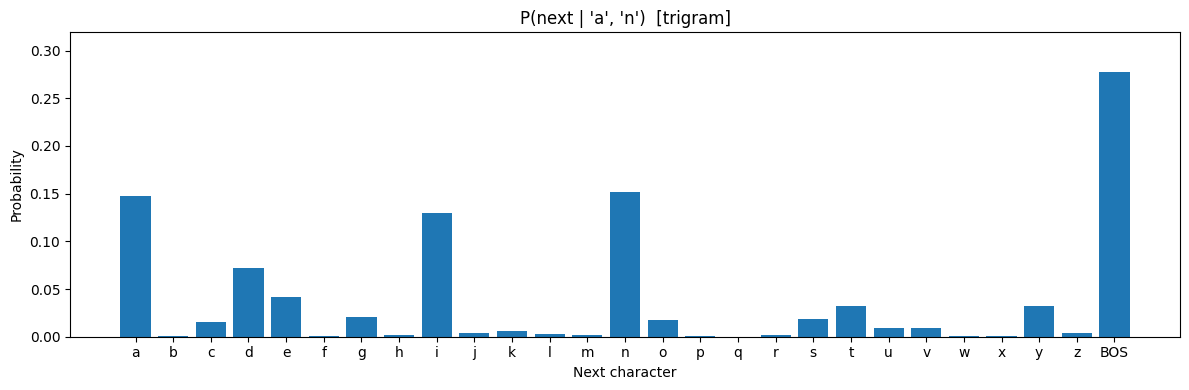

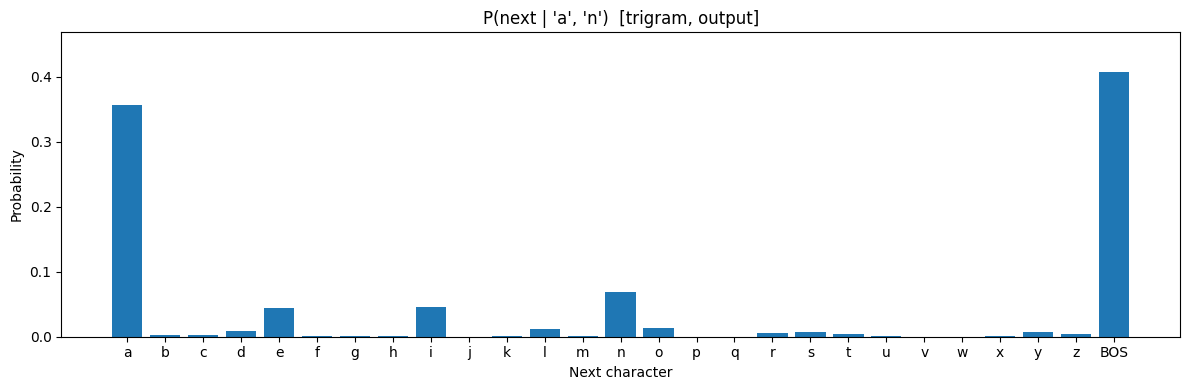

In [13]:
plot_ngram_distribution(['a', 'n'])
plot_output_ngram_distribution(['a', 'n'])